# Dunnhumby: The Complete Journey | 02 Data Audit

Before any analysis, this notebook checks that the 8 tables are complete, correctly keyed and joinable, finds the data quirks that would distort later results, and writes clean tables for the rest of the project.

**Approach:** all data work is SQL run by DuckDB directly on the Parquet files. Python is only used for one statistical test and the charts.

**Outputs**
- `data/processed/`: `fact_sales`, `dim_product`, `dim_coupon`, `dim_household`, `dim_campaign`, `dim_day` (Parquet)
- `outputs/figures/`: weekly activity and campaign timeline charts

**Headline findings** (details in the last section)
- All 8 tables join cleanly: zero orphan keys in every link.
- Fuel and other non-merchandise lines are under 2% of rows but 8.4% of sales, and must be excluded from spend metrics.
- The panel ramps up over the first 16 weeks as households are enrolled.
- Households with demographics spend over 3x more per week than those without, so demographic results describe heavy shoppers, not the whole customer base.
- Campaign targeting is strongly selective: targeted households already spend over 4x more per week than never-targeted ones, which rules out a naive targeted vs non-targeted comparison.

In [1]:
!pip -q install -U duckdb
from google.colab import drive
from pathlib import Path
from scipy.stats import mannwhitneyu
import duckdb, pandas as pd, matplotlib.pyplot as plt
drive.mount('/content/drive')
PROJ = Path('/content/drive/MyDrive/Dunnhumby Project')
PQ, OUT, FIG = PROJ/'data/parquet', PROJ/'data/processed', PROJ/'outputs/figures'
for p in (OUT, FIG): p.mkdir(parents=True, exist_ok=True)
con = duckdb.connect()
for f in sorted(PQ.glob('*.parquet')): con.execute(f"CREATE OR REPLACE VIEW {f.stem} AS SELECT * FROM '{f}'")
q = lambda s: con.sql(s).df()
pd.set_option('display.max_columns', 50, 'display.width', 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 27.2 MB/s eta 0:00:00
Mounted at /content/drive


## 1. Schema
Each Parquet file is registered as a SQL view, so queries read the files directly without loading them into memory. IDs should be integers and money columns decimals.

In [2]:
q("""
SELECT table_name, COUNT(*) AS n_cols, STRING_AGG(column_name || ' ' || data_type, ', ') AS columns
FROM information_schema.columns
GROUP BY table_name
ORDER BY table_name
""")

,table_name,n_cols,columns
0,campaign_desc,4,"DESCRIPTION VARCHAR, CAMPAIGN BIGINT, START_DA..."
1,campaign_table,3,"DESCRIPTION VARCHAR, household_key BIGINT, CAM..."
2,causal_data,5,"PRODUCT_ID BIGINT, STORE_ID BIGINT, WEEK_NO BI..."
3,coupon,3,"COUPON_UPC BIGINT, PRODUCT_ID BIGINT, CAMPAIGN..."
4,coupon_redempt,4,"household_key BIGINT, DAY BIGINT, COUPON_UPC B..."
5,hh_demographic,8,"AGE_DESC VARCHAR, MARITAL_STATUS_CODE VARCHAR,..."
6,product,7,"PRODUCT_ID BIGINT, MANUFACTURER BIGINT, DEPART..."
7,transaction_data,12,"household_key BIGINT, BASKET_ID BIGINT, DAY BI..."


## 2. Column profiles
`SUMMARIZE` returns min, max, distinct count and null percentage for every column in one pass. Things to look for: negative values in `SALES_VALUE` or `QUANTITY`, positive discounts (they should be zero or negative), and nulls.

In [3]:
q("SUMMARIZE transaction_data")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,household_key,BIGINT,1,2500,2558,1271.9525170549193,726.0659648873445,657,1273,1912,2595732,0.0
1,BASKET_ID,BIGINT,26984851472,42305362535,299513,34026199138.886974,4711649037.8633995,30411464364,32787886980,40035782339,2595732,0.0
2,DAY,BIGINT,1,711,832,388.7562217517063,189.72099531194183,229,390,552,2595732,0.0
3,PRODUCT_ID,BIGINT,25671,18316298,92804,2891435.159594673,3837403.688955562,917772,1027828,1138597,2595732,0.0
4,QUANTITY,BIGINT,0,89638,11790,100.4285581100052,1153.4362109716362,1,1,1,2595732,0.0
5,SALES_VALUE,DOUBLE,0.0,840.0,4683,3.1041197935845175,4.182274119385921,1.2721916523044117,2.039421567593387,3.4676843235964823,2595732,0.0
6,STORE_ID,BIGINT,1,34280,641,3142.673210870768,8937.113295657891,330,371,422,2595732,0.0
7,RETAIL_DISC,DOUBLE,-180.0,3.99,2228,-0.5387053979372836,1.2491914427912572,-0.6702942071155406,-0.03352796263730022,0.0,2595732,0.0
8,TRANS_TIME,VARCHAR,0000,2359,1649,None,None,None,None,None,2595732,0.0
9,WEEK_NO,BIGINT,1,102,100,56.221498983716344,27.102227899611275,34,56,80,2595732,0.0


In [4]:
q("SUMMARIZE product")

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,PRODUCT_ID,BIGINT,25671,18316298,92804,5328352.836886728,5359937.078029061,970614,1625517,9728577,92353,0.0
1,MANUFACTURER,BIGINT,1,6477,6290,1739.228330427815,1818.269569530214,334,1102,2266,92353,0.0
2,DEPARTMENT,VARCHAR,,VIDEO RENTAL,41,None,None,None,None,None,92353,0.0
3,BRAND,VARCHAR,National,Private,2,None,None,None,None,None,92353,0.0
4,COMMODITY_DESC,VARCHAR,,YOGURT,267,None,None,None,None,None,92353,0.0
5,SUB_COMMODITY_DESC,VARCHAR,,YOGURT NOT MULTI-PACKS,2171,None,None,None,None,None,92353,0.0
6,CURR_SIZE_OF_PRODUCT,VARCHAR,,XLRG,3925,None,None,None,None,None,92353,0.0


## 3. Primary keys
Each table should have one row per key. A table's grain (what one row represents) decides how it can be joined without double counting.
- `transaction_data`: one row per product in a basket, so the expected key is `(BASKET_ID, PRODUCT_ID)`
- `coupon`: one coupon covers many products, so the key is `(COUPON_UPC, PRODUCT_ID, CAMPAIGN)`

In [5]:
q("""
SELECT 'product' AS tbl, 'PRODUCT_ID' AS key, COUNT(*) AS n_rows, COUNT(DISTINCT PRODUCT_ID) AS n_keys FROM product
UNION ALL SELECT 'hh_demographic', 'household_key', COUNT(*), COUNT(DISTINCT household_key) FROM hh_demographic
UNION ALL SELECT 'campaign_desc', 'CAMPAIGN', COUNT(*), COUNT(DISTINCT CAMPAIGN) FROM campaign_desc
UNION ALL SELECT 'campaign_table', 'household_key, CAMPAIGN', COUNT(*), COUNT(DISTINCT (household_key, CAMPAIGN)) FROM campaign_table
UNION ALL SELECT 'coupon', 'COUPON_UPC, PRODUCT_ID, CAMPAIGN', COUNT(*), COUNT(DISTINCT (COUPON_UPC, PRODUCT_ID, CAMPAIGN)) FROM coupon
UNION ALL SELECT 'coupon_redempt', 'household_key, DAY, COUPON_UPC, CAMPAIGN', COUNT(*), COUNT(DISTINCT (household_key, DAY, COUPON_UPC, CAMPAIGN)) FROM coupon_redempt
UNION ALL SELECT 'causal_data', 'PRODUCT_ID, STORE_ID, WEEK_NO', COUNT(*), COUNT(DISTINCT (PRODUCT_ID, STORE_ID, WEEK_NO)) FROM causal_data
UNION ALL SELECT 'transaction_data', 'BASKET_ID, PRODUCT_ID', COUNT(*), COUNT(DISTINCT (BASKET_ID, PRODUCT_ID)) FROM transaction_data
""").assign(duplicates=lambda d: d.n_rows - d.n_keys)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,tbl,key,n_rows,n_keys,duplicates
0,product,PRODUCT_ID,92353,92353,0
1,hh_demographic,household_key,801,801,0
2,campaign_desc,CAMPAIGN,30,30,0
3,campaign_table,"household_key, CAMPAIGN",7208,7208,0
4,coupon,"COUPON_UPC, PRODUCT_ID, CAMPAIGN",124548,119384,5164
5,coupon_redempt,"household_key, DAY, COUPON_UPC, CAMPAIGN",2318,2318,0
6,causal_data,"PRODUCT_ID, STORE_ID, WEEK_NO",36786524,36771279,15245
7,transaction_data,"BASKET_ID, PRODUCT_ID",2595732,2595732,0


Duplicate `(BASKET_ID, PRODUCT_ID)` pairs are not automatically errors: the same product can be scanned twice in one basket at different prices. Fully identical rows are more suspicious, so check those separately.

In [6]:
q("""
SELECT 'transaction_data' AS tbl, COUNT(*) AS n_rows, COUNT(*) - (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM transaction_data)) AS identical_rows FROM transaction_data
UNION ALL SELECT 'coupon', COUNT(*), COUNT(*) - (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM coupon)) FROM coupon
UNION ALL SELECT 'causal_data', COUNT(*), COUNT(*) - (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM causal_data)) FROM causal_data
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,tbl,n_rows,identical_rows
0,transaction_data,2595732,0
1,coupon,124548,5164
2,causal_data,36786524,0


`coupon` has only 3 columns, so its duplicate keys are fully identical rows and are simply removed in `dim_coupon`. For `causal_data`, the question is whether a duplicated product-store-week carries conflicting promotion flags.

In [7]:
q("""
SELECT COUNT(*) AS duplicated_keys,
       COUNT(*) FILTER (WHERE n_display > 1 OR n_mailer > 1) AS conflicting_keys
FROM (
  SELECT PRODUCT_ID, STORE_ID, WEEK_NO, COUNT(DISTINCT display) AS n_display, COUNT(DISTINCT mailer) AS n_mailer
  FROM causal_data
  GROUP BY 1, 2, 3
  HAVING COUNT(*) > 1
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicated_keys,conflicting_keys
0,15245,15245


## 4. Referential integrity
Every foreign key should match a row in its parent table. `NOT EXISTS` is used instead of a `LEFT JOIN ... IS NULL` because it never multiplies rows when the parent key is not unique (as in `coupon`), and it works the same in PostgreSQL, SQL Server and BigQuery.

In [8]:
q("""
WITH hh AS (SELECT DISTINCT household_key FROM transaction_data)
SELECT 'transaction_data -> product' AS link, COUNT(*) AS n,
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM product p WHERE p.PRODUCT_ID = x.PRODUCT_ID)) AS orphans
FROM transaction_data x
UNION ALL
SELECT 'hh_demographic -> transaction_data', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM hh WHERE hh.household_key = x.household_key))
FROM hh_demographic x
UNION ALL
SELECT 'campaign_table -> campaign_desc', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM campaign_desc d WHERE d.CAMPAIGN = x.CAMPAIGN))
FROM campaign_table x
UNION ALL
SELECT 'campaign_table -> transaction_data', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM hh WHERE hh.household_key = x.household_key))
FROM campaign_table x
UNION ALL
SELECT 'coupon -> product', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM product p WHERE p.PRODUCT_ID = x.PRODUCT_ID))
FROM coupon x
UNION ALL
SELECT 'coupon_redempt -> coupon', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM coupon c WHERE c.COUPON_UPC = x.COUPON_UPC AND c.CAMPAIGN = x.CAMPAIGN))
FROM coupon_redempt x
UNION ALL
SELECT 'coupon_redempt -> campaign_table', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM campaign_table c WHERE c.household_key = x.household_key AND c.CAMPAIGN = x.CAMPAIGN))
FROM coupon_redempt x
UNION ALL
SELECT 'causal_data -> product', COUNT(*),
       COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM product p WHERE p.PRODUCT_ID = x.PRODUCT_ID))
FROM causal_data x
""").assign(orphan_pct=lambda d: (100 * d.orphans / d.n).round(2))

,link,n,orphans,orphan_pct
0,transaction_data -> product,2595732,0,0.0
1,hh_demographic -> transaction_data,801,0,0.0
2,campaign_table -> campaign_desc,7208,0,0.0
3,campaign_table -> transaction_data,7208,0,0.0
4,coupon -> product,124548,0,0.0
5,coupon_redempt -> coupon,2318,0,0.0
6,coupon_redempt -> campaign_table,2318,0,0.0
7,causal_data -> product,36786524,0,0.0


`coupon_redempt -> campaign_table` matters most: a redemption by a household that was never targeted by that campaign would mean coupons leaked outside the target list, which breaks a clean treated vs control split.

## 5. Household coverage
Who is in which table decides what each analysis can use. Never-targeted households are the natural control group for the campaign analysis.

In [9]:
cov = q("""
WITH hh AS (
  SELECT t.household_key,
         d.AGE_DESC IS NOT NULL AS has_demo,
         EXISTS (SELECT 1 FROM campaign_table c WHERE c.household_key = t.household_key) AS targeted,
         EXISTS (SELECT 1 FROM coupon_redempt r WHERE r.household_key = t.household_key) AS redeemed
  FROM (SELECT DISTINCT household_key FROM transaction_data) t
  LEFT JOIN hh_demographic d ON d.household_key = t.household_key
)
SELECT COUNT(*) AS households,
       COUNT(*) FILTER (WHERE has_demo) AS with_demo,
       COUNT(*) FILTER (WHERE targeted) AS targeted,
       COUNT(*) FILTER (WHERE NOT targeted) AS never_targeted,
       COUNT(*) FILTER (WHERE redeemed) AS redeemed_any,
       COUNT(*) FILTER (WHERE has_demo AND targeted) AS demo_and_targeted
FROM hh
""")
cov

,households,with_demo,targeted,never_targeted,redeemed_any,demo_and_targeted
0,2500,801,1584,916,434,760


### Are households with demographics representative?
Only about a third of households have demographics. If they spend differently from the rest, any demographic breakdown later describes a biased subset. Weekly spend is heavily right-skewed, so a Mann-Whitney U test is used instead of a t-test, with the rank-biserial correlation as effect size (0 means no difference, ±1 means complete separation).

The same table also compares targeted and never-targeted households. If targeted households already spent more, campaign selection was based on behaviour, and a simple targeted vs non-targeted comparison would credit the campaign with a difference that existed anyway.

In [10]:
hh_spend = q("""
SELECT t.household_key, d.AGE_DESC IS NOT NULL AS has_demo,
       EXISTS (SELECT 1 FROM campaign_table c WHERE c.household_key = t.household_key) AS targeted,
       SUM(t.SALES_VALUE) / (MAX(t.WEEK_NO) - MIN(t.WEEK_NO) + 1) AS weekly_spend,
       COUNT(DISTINCT t.BASKET_ID) AS baskets
FROM transaction_data t
LEFT JOIN hh_demographic d ON d.household_key = t.household_key
GROUP BY 1, 2, 3
""")
a, b = hh_spend.weekly_spend[hh_spend.has_demo], hh_spend.weekly_spend[~hh_spend.has_demo]
mw = mannwhitneyu(a, b)
print(f"Mann-Whitney U p = {mw.pvalue:.3g}, rank-biserial r = {2 * mw.statistic / (len(a) * len(b)) - 1:.3f}")
display(hh_spend.groupby('has_demo')[['weekly_spend', 'baskets']].agg(['count', 'median', 'mean']).round(1))
hh_spend.groupby('targeted')[['weekly_spend', 'baskets']].agg(['count', 'median', 'mean']).round(1)

Mann-Whitney U p = 2.09e-175, rank-biserial r = 0.699


weekly_spend              baskets              
                count median  mean   count median   mean
has_demo                                                
False            1699   15.6  23.3    1699   52.0   80.1
True              801   51.7  61.0     801  139.0  175.2

weekly_spend              baskets              
                count median  mean   count median   mean
targeted                                                
False             916    8.7  11.9     916   32.0   39.4
True             1584   37.6  48.9    1584  119.0  151.8

## 6. Transaction values
Known quirks in this dataset:
- Discounts are stored as negative numbers, so a positive discount is an error.
- Returns would show up as negative `SALES_VALUE` or `QUANTITY`. This version of the data has none, but it does have lines with zero quantity or zero sales value, which are not real purchases.
- Fuel is recorded with huge `QUANTITY` values, which would wreck any average basket size.

In [11]:
q("""
SELECT COUNT(*) AS n_rows,
       COUNT(*) FILTER (WHERE SALES_VALUE < 0) AS negative_sales,
       COUNT(*) FILTER (WHERE SALES_VALUE = 0) AS zero_sales,
       COUNT(*) FILTER (WHERE QUANTITY < 0) AS negative_qty,
       COUNT(*) FILTER (WHERE QUANTITY = 0) AS zero_qty,
       COUNT(*) FILTER (WHERE RETAIL_DISC > 0) AS positive_retail_disc,
       COUNT(*) FILTER (WHERE COUPON_DISC > 0) AS positive_coupon_disc,
       COUNT(*) FILTER (WHERE COUPON_MATCH_DISC > 0) AS positive_match_disc,
       COUNT(*) FILTER (WHERE COUPON_DISC < 0) AS rows_with_coupon
FROM transaction_data
""")

,n_rows,negative_sales,zero_sales,negative_qty,zero_qty,positive_retail_disc,positive_coupon_disc,positive_match_disc,rows_with_coupon
0,2595732,0,18850,0,14466,36,0,0,36422


In [12]:
q("""
SELECT p.DEPARTMENT, p.COMMODITY_DESC, p.SUB_COMMODITY_DESC, COUNT(*) AS n_rows,
       MEDIAN(t.QUANTITY) AS median_qty, MAX(t.QUANTITY) AS max_qty, ROUND(SUM(t.SALES_VALUE)) AS sales
FROM transaction_data t
JOIN product p ON p.PRODUCT_ID = t.PRODUCT_ID
WHERE t.QUANTITY > 100
GROUP BY 1, 2, 3
ORDER BY n_rows DESC
LIMIT 10
""")

,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC,n_rows,median_qty,max_qty,sales
0,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,20261,10551.0,89638,514685.0
1,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,2868,12504.5,85055,89341.0
2,KIOSK-GAS,FUEL,GASOLINE-REG UNLEADED,6,18777.5,30080,288.0
3,PRODUCE,CORN,CORN WHITE,1,144.0,144,24.0


In [13]:
q("""
SELECT p.DEPARTMENT, COUNT(*) AS n_rows, ROUND(SUM(t.SALES_VALUE)) AS sales,
       ROUND(100 * SUM(t.SALES_VALUE) / SUM(SUM(t.SALES_VALUE)) OVER (), 2) AS sales_pct,
       QUANTILE_CONT(t.QUANTITY, 0.99) AS p99_qty
FROM transaction_data t
JOIN product p ON p.PRODUCT_ID = t.PRODUCT_ID
GROUP BY 1
ORDER BY sales DESC
""")

,DEPARTMENT,n_rows,sales,sales_pct,p99_qty
0,GROCERY,1646076,4093814.0,50.81,5.00
1,DRUG GM,277232,1055358.0,13.10,4.00
2,PRODUCE,257290,557452.0,6.92,5.00
3,MEAT,88416,548787.0,6.81,4.00
4,KIOSK-GAS,22059,544222.0,6.75,24638.26
5,MEAT-PCKGD,111957,412437.0,5.12,4.00
6,DELI,62787,260867.0,3.24,2.00
7,PASTRY,38179,121740.0,1.51,6.00
8,MISC SALES TRAN,6050,119960.0,1.49,24801.77
9,NUTRITION,32164,97669.0,1.21,5.00


### Non-merchandise flag
Fuel (including other kiosk items), coupons, charity donations, postal services, miscellaneous transaction lines and products with a blank department are not grocery purchases. They are **flagged, not deleted**, so later notebooks can exclude them from basket and spend metrics while totals still reconcile with the raw data.

The list below was built from the department table above. The next query confirms the flag catches the extreme quantities: only one unflagged line has a quantity above 100 (144 ears of corn, which is plausible).

In [14]:
con.execute("""
CREATE OR REPLACE VIEW product_clean AS
SELECT PRODUCT_ID AS product_id, MANUFACTURER AS manufacturer, TRIM(DEPARTMENT) AS department, TRIM(BRAND) AS brand,
       TRIM(COMMODITY_DESC) AS commodity, TRIM(SUB_COMMODITY_DESC) AS sub_commodity, NULLIF(TRIM(CURR_SIZE_OF_PRODUCT), '') AS size,
       COALESCE(TRIM(DEPARTMENT) IN ('KIOSK-GAS', 'MISC SALES TRAN', 'MISC. TRANS.', 'COUP/STR & MFG', 'CHARITABLE CONT', 'POSTAL CENTER', '')
                OR TRIM(COMMODITY_DESC) IN ('COUPON/MISC ITEMS', 'NO COMMODITY DESCRIPTION')
                OR SUB_COMMODITY_DESC ILIKE '%GASOLINE%', FALSE) AS is_nonmerch
FROM product
""")
q("""
SELECT COALESCE(p.is_nonmerch, FALSE) AS is_nonmerch, COUNT(*) AS n_rows,
       ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS rows_pct,
       ROUND(100 * SUM(t.SALES_VALUE) / SUM(SUM(t.SALES_VALUE)) OVER (), 2) AS sales_pct,
       COUNT(*) FILTER (WHERE t.QUANTITY > 100) AS rows_qty_over_100, MAX(t.QUANTITY) AS max_qty,
       COUNT(*) FILTER (WHERE t.QUANTITY = 0 OR t.SALES_VALUE = 0) AS zero_value_rows
FROM transaction_data t
LEFT JOIN product_clean p ON p.product_id = t.PRODUCT_ID
GROUP BY 1
""")

,is_nonmerch,n_rows,rows_pct,sales_pct,rows_qty_over_100,max_qty,zero_value_rows
0,False,2555066,98.43,91.55,1,144,10420
1,True,40666,1.57,8.45,23135,89638,8497


## 7. Time coverage
`DAY` (1 to 711) and `WEEK_NO` (1 to 102) are relative numbers, not calendar dates. First check that every day belongs to exactly one week, then look at weekly activity. Panels often start slowly while households are being enrolled, and those early weeks should not be treated as normal behaviour.

In [15]:
q("""
SELECT COUNT(*) AS days, COUNT(*) FILTER (WHERE n_weeks > 1) AS days_in_multiple_weeks
FROM (SELECT DAY, COUNT(DISTINCT WEEK_NO) AS n_weeks FROM transaction_data GROUP BY DAY)
""")

,days,days_in_multiple_weeks
0,711,0


In [16]:
q("""
SELECT WEEK_NO AS week_no, MIN(DAY) AS first_day, MAX(DAY) AS last_day, COUNT(DISTINCT DAY) AS days
FROM transaction_data
GROUP BY 1
HAVING COUNT(DISTINCT DAY) < 7
ORDER BY 1
""")

,week_no,first_day,last_day,days
0,1,1,5,5
1,102,706,711,6


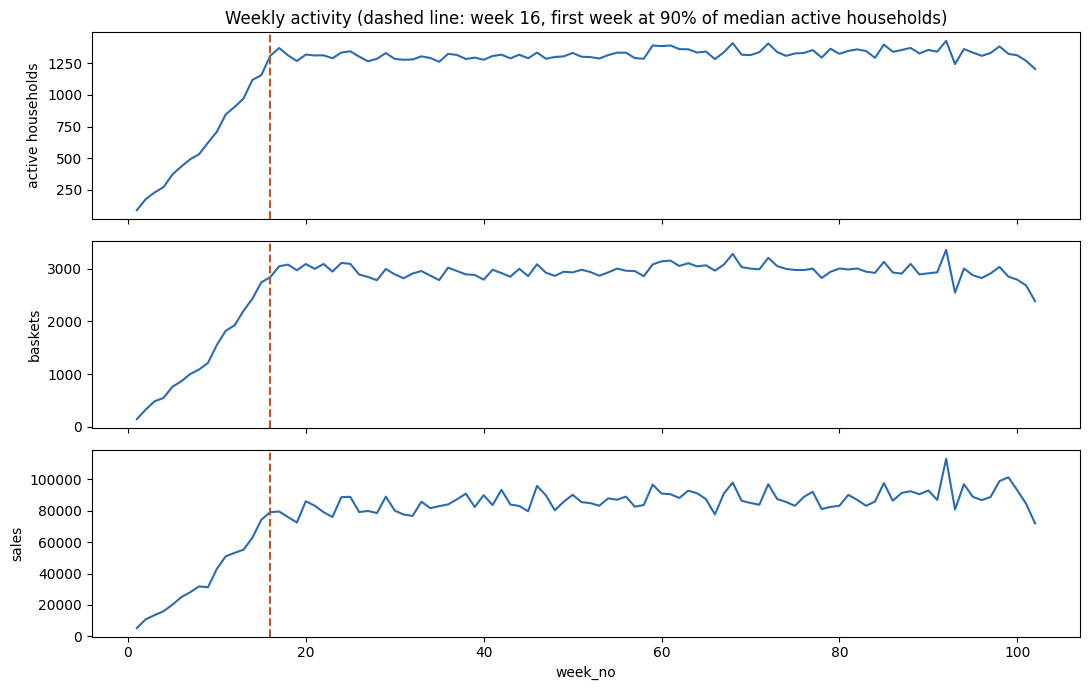

,week_no,active_households,baskets,sales
0,1,88,142,5211.16
1,2,175,324,10821.35
2,3,228,482,13498.20
99,100,1313,2793,93063.10
100,101,1269,2682,84407.25
101,102,1205,2383,71968.63


In [17]:
weekly = q("""
SELECT WEEK_NO AS week_no, COUNT(DISTINCT household_key) AS active_households,
       COUNT(DISTINCT BASKET_ID) AS baskets, SUM(SALES_VALUE) AS sales
FROM transaction_data
GROUP BY 1
ORDER BY 1
""")
ramp_week = weekly.week_no[weekly.active_households >= 0.9 * weekly.active_households.median()].min()
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, col in zip(axes, ['active_households', 'baskets', 'sales']):
    ax.plot(weekly.week_no, weekly[col], color='#2b6cb0')
    ax.axvline(ramp_week, color='#c05621', ls='--')
    ax.set_ylabel(col.replace('_', ' '))
axes[0].set_title(f'Weekly activity (dashed line: week {ramp_week}, first week at 90% of median active households)')
axes[-1].set_xlabel('week_no')
plt.tight_layout(); plt.savefig(FIG/'02_weekly_activity.png', dpi=150); plt.show()
pd.concat([weekly.head(3), weekly.tail(3)])

In [18]:
q("""
SELECT CASE WHEN first_week <= 4 THEN '01-04' WHEN first_week <= 12 THEN '05-12' WHEN first_week <= 26 THEN '13-26' ELSE '27+' END AS first_seen_week,
       COUNT(*) AS households
FROM (SELECT household_key, MIN(WEEK_NO) AS first_week FROM transaction_data GROUP BY 1)
GROUP BY 1
ORDER BY 1
""")

,first_seen_week,households
0,01-04,448
1,05-12,1139
2,13-26,907
3,27+,6


Households entered the panel gradually: only 448 appear in weeks 1 to 4, and 907 first appear between weeks 13 and 26. A household's first week in the data is therefore when it joined the panel, not when it became a customer. Classic acquisition cohorts would mix enrolment timing with real customer behaviour, which is why notebook 04 uses survival analysis instead.

Weekly totals should only be compared from the first stable week onwards. Household-level rates such as weekly spend are measured over each household's own active span, so they are not distorted by late entry.

## 8. Campaigns
Campaign timing and overlap drive the design of the causal analysis. If most targeted households receive several overlapping campaigns, the effect of one campaign cannot be isolated without restricting to clean windows.

In [19]:
camp = q("""
SELECT d.CAMPAIGN AS campaign, d.DESCRIPTION AS type, d.START_DAY AS start_day, d.END_DAY AS end_day,
       d.END_DAY - d.START_DAY + 1 AS duration_days,
       (SELECT COUNT(*) FROM campaign_table c WHERE c.CAMPAIGN = d.CAMPAIGN) AS hh_targeted,
       (SELECT COUNT(*) FROM campaign_table c WHERE c.CAMPAIGN = d.CAMPAIGN AND c.DESCRIPTION <> d.DESCRIPTION) AS type_mismatch,
       (SELECT COUNT(DISTINCT COUPON_UPC) FROM coupon c WHERE c.CAMPAIGN = d.CAMPAIGN) AS coupons,
       (SELECT COUNT(DISTINCT household_key) FROM coupon_redempt r WHERE r.CAMPAIGN = d.CAMPAIGN) AS hh_redeemed
FROM campaign_desc d
ORDER BY start_day
""").assign(redemption_rate_pct=lambda d: (100 * d.hh_redeemed / d.hh_targeted).round(1))
camp

,campaign,type,start_day,end_day,duration_days,hh_targeted,type_mismatch,coupons,hh_redeemed,redemption_rate_pct
0,26,TypeA,224,264,41,332,0,181,31,9.3
1,27,TypeC,237,300,64,12,0,27,1,8.3
2,28,TypeB,259,320,62,17,0,28,1,5.9
3,29,TypeB,281,334,54,118,0,33,13,11.0
4,30,TypeA,323,369,47,361,0,181,36,10.0
5,1,TypeB,346,383,38,13,0,11,1,7.7
6,2,TypeB,351,383,33,48,0,16,2,4.2
7,3,TypeC,356,412,57,12,0,34,2,16.7
8,4,TypeB,372,404,33,81,0,12,6,7.4
9,5,TypeB,377,411,35,166,0,11,8,4.8


In [20]:
q("""
SELECT type, COUNT(*) AS campaigns, ROUND(AVG(duration_days)) AS avg_days, SUM(hh_targeted) AS hh_targeted,
       SUM(hh_redeemed) AS hh_redeemed, ROUND(100 * SUM(hh_redeemed) / SUM(hh_targeted), 1) AS redemption_rate_pct
FROM camp
GROUP BY 1
ORDER BY 1
""")

,type,campaigns,avg_days,hh_targeted,hh_redeemed,redemption_rate_pct
0,TypeA,5,48.0,3979.0,635.0,16.0
1,TypeB,19,39.0,2655.0,210.0,7.9
2,TypeC,6,76.0,574.0,44.0,7.7


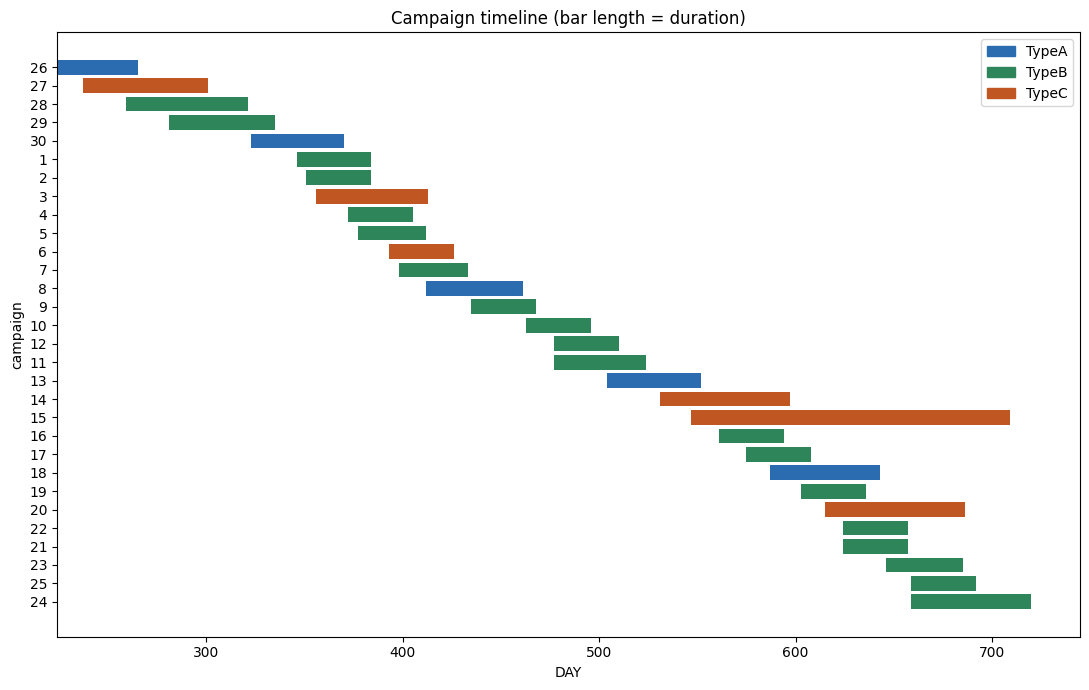

In [21]:
colors = {'TypeA': '#2b6cb0', 'TypeB': '#2f855a', 'TypeC': '#c05621'}
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(camp)), camp.duration_days, left=camp.start_day, color=camp.type.map(colors))
ax.set_yticks(range(len(camp)), camp.campaign)
ax.invert_yaxis()
ax.set(xlabel='DAY', ylabel='campaign', title='Campaign timeline (bar length = duration)')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()], labels=list(colors))
plt.tight_layout(); plt.savefig(FIG/'02_campaign_timeline.png', dpi=150); plt.show()

### Campaign overlap per household
A self-join on `campaign_table` finds pairs of campaigns received by the same household whose date windows intersect (`a.start <= b.end AND b.start <= a.end`).

In [22]:
q("""
WITH hc AS (
  SELECT c.household_key, d.CAMPAIGN, d.START_DAY, d.END_DAY
  FROM campaign_table c
  JOIN campaign_desc d ON d.CAMPAIGN = c.CAMPAIGN
),
per_hh AS (
  SELECT a.household_key, COUNT(DISTINCT a.CAMPAIGN) AS campaigns,
         COUNT(b.CAMPAIGN) AS overlapping_pairs
  FROM hc a
  LEFT JOIN hc b ON b.household_key = a.household_key AND b.CAMPAIGN > a.CAMPAIGN
                AND a.START_DAY <= b.END_DAY AND b.START_DAY <= a.END_DAY
  GROUP BY 1
)
SELECT COUNT(*) AS targeted_households,
       MEDIAN(campaigns) AS median_campaigns,
       MAX(campaigns) AS max_campaigns,
       COUNT(*) FILTER (WHERE campaigns = 1) AS single_campaign,
       COUNT(*) FILTER (WHERE overlapping_pairs > 0) AS with_overlap,
       ROUND(100 * COUNT(*) FILTER (WHERE overlapping_pairs > 0) / COUNT(*), 1) AS with_overlap_pct
FROM per_hh
""")

,targeted_households,median_campaigns,max_campaigns,single_campaign,with_overlap,with_overlap_pct
0,1584,4.0,17,268,884,55.8


In [23]:
q("""
SELECT COUNT(*) AS redemptions,
       COUNT(*) FILTER (WHERE r.DAY < d.START_DAY) AS before_start,
       COUNT(*) FILTER (WHERE r.DAY > d.END_DAY) AS after_end
FROM coupon_redempt r
JOIN campaign_desc d ON d.CAMPAIGN = r.CAMPAIGN
""")

,redemptions,before_start,after_end
0,2318,0,0


## 9. Build clean tables
Design choices:
- **Flag, don't delete.** Zero-value lines and non-merchandise rows stay in `fact_sales` with `is_zero_line` and `is_nonmerch` flags, so every later filter is explicit and totals still reconcile.
- **snake_case column names** so later SQL is easier to read.
- **Prices** follow the Dunnhumby user guide. `SALES_VALUE` is what the retailer receives, not the shelf price. Shelf price (non-loyalty) = `(SALES_VALUE - RETAIL_DISC - COUPON_MATCH_DISC) / QUANTITY`, and loyalty card price = `(SALES_VALUE - COUPON_MATCH_DISC) / QUANTITY`. Discounts are negative, so subtracting them adds the discount back. Prices are left null when `QUANTITY` is zero or negative.
- `TRANS_TIME` is stored as text (`'0000'` to `'2359'`), so an integer `trans_hour` is added for time-of-day analysis.
- `dim_coupon` removes the identical duplicate rows found in `coupon`.
- `dim_household` covers all households, with demographic columns null where missing and a `has_demo` flag.

In [24]:
con.execute(f"""
COPY (
  SELECT t.household_key, t.BASKET_ID AS basket_id, t.DAY AS day, t.WEEK_NO AS week_no, t.TRANS_TIME AS trans_time,
         CAST(t.TRANS_TIME AS INTEGER) // 100 AS trans_hour,
         t.STORE_ID AS store_id, t.PRODUCT_ID AS product_id, t.QUANTITY AS quantity, t.SALES_VALUE AS sales_value,
         t.RETAIL_DISC AS retail_disc, t.COUPON_DISC AS coupon_disc, t.COUPON_MATCH_DISC AS coupon_match_disc,
         CASE WHEN t.QUANTITY > 0 THEN (t.SALES_VALUE - t.RETAIL_DISC - t.COUPON_MATCH_DISC) / t.QUANTITY END AS shelf_price,
         CASE WHEN t.QUANTITY > 0 THEN (t.SALES_VALUE - t.COUPON_MATCH_DISC) / t.QUANTITY END AS loyalty_price,
         t.QUANTITY <= 0 OR t.SALES_VALUE <= 0 AS is_zero_line,
         COALESCE(p.is_nonmerch, FALSE) AS is_nonmerch
  FROM transaction_data t
  LEFT JOIN product_clean p ON p.product_id = t.PRODUCT_ID
) TO '{OUT}/fact_sales.parquet' (FORMAT PARQUET);

COPY (SELECT * FROM product_clean) TO '{OUT}/dim_product.parquet' (FORMAT PARQUET);

COPY (SELECT DISTINCT COUPON_UPC AS coupon_upc, PRODUCT_ID AS product_id, CAMPAIGN AS campaign FROM coupon) TO '{OUT}/dim_coupon.parquet' (FORMAT PARQUET);

COPY (
  WITH act AS (SELECT household_key, MIN(DAY) AS first_day, MAX(DAY) AS last_day FROM transaction_data GROUP BY 1),
       camp AS (SELECT household_key, COUNT(*) AS n_campaigns FROM campaign_table GROUP BY 1)
  SELECT a.household_key, a.first_day, a.last_day, COALESCE(c.n_campaigns, 0) AS n_campaigns,
         d.AGE_DESC IS NOT NULL AS has_demo, d.AGE_DESC AS age, d.MARITAL_STATUS_CODE AS marital_status,
         d.INCOME_DESC AS income, d.HOMEOWNER_DESC AS homeowner, d.HH_COMP_DESC AS hh_composition,
         d.HOUSEHOLD_SIZE_DESC AS hh_size, d.KID_CATEGORY_DESC AS kids
  FROM act a
  LEFT JOIN camp c ON c.household_key = a.household_key
  LEFT JOIN hh_demographic d ON d.household_key = a.household_key
) TO '{OUT}/dim_household.parquet' (FORMAT PARQUET);

COPY (
  SELECT d.CAMPAIGN AS campaign, d.DESCRIPTION AS type, d.START_DAY AS start_day, d.END_DAY AS end_day,
         d.END_DAY - d.START_DAY + 1 AS duration_days,
         (SELECT COUNT(*) FROM campaign_table c WHERE c.CAMPAIGN = d.CAMPAIGN) AS hh_targeted,
         (SELECT COUNT(DISTINCT household_key) FROM coupon_redempt r WHERE r.CAMPAIGN = d.CAMPAIGN) AS hh_redeemed
  FROM campaign_desc d
) TO '{OUT}/dim_campaign.parquet' (FORMAT PARQUET);

COPY (SELECT DISTINCT DAY AS day, WEEK_NO AS week_no FROM transaction_data ORDER BY 1) TO '{OUT}/dim_day.parquet' (FORMAT PARQUET);
""")
q(f"""
SELECT REGEXP_EXTRACT(filename, '([a-z_]+)\\.parquet$', 1) AS table_name, COUNT(*) AS n_rows
FROM read_parquet('{OUT}/*.parquet', filename = true, union_by_name = true)
GROUP BY 1
ORDER BY 1
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,n_rows
0,dim_campaign,30
1,dim_coupon,119384
2,dim_day,711
3,dim_household,2500
4,dim_product,92353
5,fact_sales,2595732


Reconciliation check: total sales in `fact_sales` must equal the raw table exactly, since no rows were dropped.

In [25]:
q(f"""
SELECT (SELECT ROUND(SUM(SALES_VALUE), 2) FROM transaction_data) AS raw_sales,
       (SELECT ROUND(SUM(sales_value), 2) FROM '{OUT}/fact_sales.parquet') AS processed_sales,
       (SELECT ROUND(SUM(sales_value), 2) FROM '{OUT}/fact_sales.parquet' WHERE NOT is_nonmerch AND NOT is_zero_line) AS merchandise_sales
""")

,raw_sales,processed_sales,merchandise_sales
0,8057463.08,8057463.08,7376290.62


## 10. Summary

In [26]:
pd.Series({
    'households': cov.households[0],
    'with demographics': cov.with_demo[0],
    'targeted by any campaign': cov.targeted[0],
    'never targeted (control pool)': cov.never_targeted[0],
    'demo vs non-demo weekly spend, Mann-Whitney p': f'{mw.pvalue:.1e}',
    'first stable week': ramp_week,
    'campaigns': len(camp),
}, dtype=object).to_frame('value')

,value
households,2500
with demographics,801
targeted by any campaign,1584
never targeted (control pool),916
"demo vs non-demo weekly spend, Mann-Whitney p",2.1e-175
first stable week,16
campaigns,30


## Findings and decisions for the next notebooks

1. **Keys and joins are clean.** Every foreign key matches its parent table (0 orphans in all 8 links) and `transaction_data` has no duplicate lines. The only duplicates are 5,164 identical rows in `coupon`, removed in `dim_coupon`, and 15,245 duplicated product-store-weeks in `causal_data`. Every one of those has conflicting display or mailer flags, so they are not simple copies. The promotion analysis will treat a product-store-week as promoted if any of its rows says so.
2. **Non-merchandise lines are small in volume but large in value.** Fuel, kiosk, coupon and miscellaneous lines are under 2% of rows but 8.4% of sales (about $680K of $8.06M), with quantities up to 89,638 on a single fuel line. From notebook 03 onwards every spend, basket and product metric filters `NOT is_nonmerch AND NOT is_zero_line`.
3. **No returns, but many zero-value lines.** There are no negative sales or quantities. 18,850 lines have zero sales and 14,466 have zero quantity, mostly the same lines: 18,917 in total, flagged with `is_zero_line`. Excluding them removes only about $1,000 of sales. 36 lines have a positive retail discount, which is a data error too small (0.001% of rows) to matter.
4. **Ramp-up period.** Active households climb from 88 in week 1 to a stable level of about 1,300 by week 16. Week 1 (5 days) and week 102 (6 days) are partial weeks, so weekly totals are compared over weeks 16 to 101. All campaigns start after day 224 (around week 32), so the campaign pre-periods fall entirely in the stable period.
5. **Demographics describe heavy shoppers.** Only 801 of 2,500 households (32%) have demographics, and they spend a median of $51.7 per week against $15.6 for the rest (Mann-Whitney p < 0.001, rank-biserial r = 0.70, a large effect). Any result broken down by age, income or household type describes this engaged group, not the whole customer base, and is labelled as such. Segmentation uses behaviour, which is available for all households.
6. **Campaign targeting is strongly selective.** 760 of the 801 demographic households (95%) were targeted, against 824 of the other 1,699 (48%). Targeted households spend a median of $37.6 per week against $8.7 for the 916 never-targeted ones, more than 4x. Comparing targeted and non-targeted households directly would mostly measure who was chosen, not what the campaign did. Notebook 06 therefore matches on pre-campaign behaviour and checks common support, since the never-targeted pool is made of much lighter shoppers and some targeted households may have no comparable control.
7. **Campaign structure.** 30 campaigns: 5 TypeA campaigns (three of them reaching over 1,000 households each, 16% redemption overall) and 25 smaller TypeB and TypeC campaigns (around 8% redemption). Targeted households received a median of 4 campaigns (maximum 17), and 56% had at least two campaigns running at the same time. The 44% without overlapping windows are the candidates for clean single-campaign comparisons. Redemption rates are descriptive only and say nothing yet about extra spending.

## Business recommendation
For the retailer's data team:
- **Collect demographics for all loyalty members, not just the most engaged.** The current 32% sample is biased towards households that spend 3x more, so any demographic targeting rule built on it will misread the typical customer.
- **Store fuel and service lines with their own unit of measure**, or in a separate table. Fuel is 8.4% of sales but its quantities are recorded on a different scale, which silently breaks KPIs like units per basket.
- **Keep a random hold-out group for every campaign.** Targeting favoured heavy shoppers and most households received overlapping campaigns, so the true effect has to be estimated with quasi-experimental methods. A small random hold-out (for example 5 to 10% of each target list) would make the effect directly measurable at almost no cost.